# 19. Backtesting and Strategy Evaluation

## Objective
Evaluate whether model-driven decisions translate into financial edge under a realistic backtesting setup.

Trading rules:
- `BUY` -> take long return
- `SELL` -> take inverse return
- `NO TRADE` -> return = 0

Focus: decision quality and strategy profitability.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 250)
pd.set_option('display.width', 220)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

logger = logging.getLogger('backtesting_engine')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)

## 1) Load Data

In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to resolve project root containing ml_pipeline and CLAUDE.md')


def resolve_paths(root: Path) -> Dict[str, Path]:
    base = root / 'ml_pipeline'
    return {
        'decision_dataset': base / 'Market_Data' / 'final' / 'final_decision_dataset.parquet',
        'processed_dataset': base / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet',
    }


ROOT = resolve_project_root()
PATHS = resolve_paths(ROOT)

# assert PATHS['decision_dataset'].exists(), f'Missing file: {PATHS['"']decision_dataset['"']}'
assert PATHS['decision_dataset'].exists(), f"Missing file: {PATHS['decision_dataset']}"
# assert PATHS['processed_dataset'].exists(), f'Missing file: {PATHS['"']processed_dataset['"']}'
assert PATHS['processed_dataset'].exists(), f"Missing file: {PATHS['processed_dataset']}"

decision_df = pd.read_parquet(PATHS['decision_dataset']).copy()
decision_df['Date'] = pd.to_datetime(decision_df['Date'])

market_df = pd.read_parquet(PATHS['processed_dataset'], columns=['Ticker', 'Date', 'Close', 'volatility_regime_label']).copy()
market_df['Date'] = pd.to_datetime(market_df['Date'])
market_df = market_df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

required_cols = {'Ticker', 'Date', 'Regime', 'Decision', 'target'}
assert required_cols.issubset(decision_df.columns), f'Decision dataset missing columns: {required_cols - set(decision_df.columns)}'

logger.info('Decision rows: %s', f'{len(decision_df):,}')
logger.info('Market rows: %s', f'{len(market_df):,}')
display(decision_df.head())

[INFO] Decision rows: 21,888
[INFO] Market rows: 63,541


,Ticker,Date,Regime,Probability,Decision,Selected,Decision_Pred,Prediction,Confidence,Model Used,target
0,ABB,2025-01-29,HIGH,0.494498,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,0
1,ABB,2025-01-30,HIGH,0.502987,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,1
2,ABB,2025-01-31,HIGH,0.492936,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,0
3,ABB,2025-02-01,HIGH,0.506073,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,0
4,ABB,2025-02-03,HIGH,0.496291,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,1


## 2) Compute Next-Day Returns

Daily return definition:
\[ (Close[t+1] - Close[t]) / Close[t] \]

In [3]:
market_df['Close_t1'] = market_df.groupby('Ticker', sort=False)['Close'].shift(-1)
market_df['daily_return'] = (market_df['Close_t1'] - market_df['Close']) / market_df['Close']

returns_df = market_df[['Ticker', 'Date', 'daily_return', 'volatility_regime_label']].copy()
returns_df = returns_df.dropna(subset=['daily_return']).reset_index(drop=True)

bt_df = decision_df.merge(returns_df, on=['Ticker', 'Date'], how='left')
missing_returns = int(bt_df['daily_return'].isna().sum())
if missing_returns > 0:
    logger.info('Dropping %d rows without t+1 close (end-of-series dates).', missing_returns)
    bt_df = bt_df.dropna(subset=['daily_return']).reset_index(drop=True)

# Use decision regime as primary; keep source regime for sanity check
bt_df = bt_df.rename(columns={'volatility_regime_label': 'Regime_source'})
regime_match = (bt_df['Regime'].astype(str).str.upper() == bt_df['Regime_source'].astype(str).str.upper()).mean()
logger.info('Regime match rate with source data: %.2f%%', 100 * regime_match)
assert bt_df['daily_return'].isna().sum() == 0, 'Unexpected NaNs remain in daily_return after cleanup.'

display(bt_df[['Ticker', 'Date', 'Regime', 'Decision', 'daily_return']].head())

[INFO] Dropping 96 rows without t+1 close (end-of-series dates).
[INFO] Regime match rate with source data: 100.00%


,Ticker,Date,Regime,Decision,daily_return
0,ABB,2025-01-29,HIGH,NO TRADE,-0.064066
1,ABB,2025-01-30,HIGH,NO TRADE,0.027153
2,ABB,2025-01-31,HIGH,NO TRADE,-0.063859
3,ABB,2025-02-01,HIGH,NO TRADE,-0.054941
4,ABB,2025-02-03,HIGH,NO TRADE,0.083158


## 3) Trading Logic and Strategy Returns

In [4]:
def map_decision_to_return(df_in: pd.DataFrame, decision_col: str) -> pd.Series:
    d = df_in[decision_col].astype(str).str.upper()
    return np.where(
        d == 'BUY',
        df_in['daily_return'].to_numpy(),
        np.where(d == 'SELL', -df_in['daily_return'].to_numpy(), 0.0),
    )


# Main strategy from selective decision layer
bt_df['strategy_return'] = map_decision_to_return(bt_df, decision_col='Decision')
bt_df['trade_executed'] = bt_df['Decision'].isin(['BUY', 'SELL'])

# Benchmark 1: Buy & Hold (always long underlying)
bt_df['buy_hold_return'] = bt_df['daily_return']

# Benchmark 2: Random strategy (match trade coverage + buy/sell mix)
trade_rate = bt_df['trade_executed'].mean()
buy_rate_given_trade = (bt_df.loc[bt_df['trade_executed'], 'Decision'].str.upper() == 'BUY').mean()
random_u = np.random.rand(len(bt_df))
random_trade = random_u < trade_rate
random_side = np.where(np.random.rand(len(bt_df)) < buy_rate_given_trade, 'BUY', 'SELL')
bt_df['random_decision'] = np.where(random_trade, random_side, 'NO TRADE')
bt_df['random_trade'] = bt_df['random_decision'] != 'NO TRADE'
bt_df['random_return'] = map_decision_to_return(bt_df, decision_col='random_decision')

logger.info('Trade coverage: %.2f%% | Buy ratio among trades: %.2f%%', 100 * trade_rate, 100 * buy_rate_given_trade)
display(bt_df[['Ticker', 'Date', 'Decision', 'strategy_return', 'buy_hold_return', 'random_decision', 'random_return']].head(12))

[INFO] Trade coverage: 35.79% | Buy ratio among trades: 44.81%


,Ticker,Date,Decision,strategy_return,buy_hold_return,random_decision,random_return
0,ABB,2025-01-29,NO TRADE,0.0,-0.064066,NO TRADE,0.000000
1,ABB,2025-01-30,NO TRADE,0.0,0.027153,NO TRADE,0.000000
2,ABB,2025-01-31,NO TRADE,0.0,-0.063859,NO TRADE,0.000000
3,ABB,2025-02-01,NO TRADE,0.0,-0.054941,NO TRADE,0.000000
4,ABB,2025-02-03,NO TRADE,0.0,0.083158,BUY,0.083158
5,ABB,2025-02-04,NO TRADE,0.0,0.020499,SELL,-0.020499
6,ABB,2025-02-05,NO TRADE,0.0,-0.011062,SELL,0.011062
7,ABB,2025-02-06,NO TRADE,0.0,0.000766,NO TRADE,0.000000
8,ABB,2025-02-07,NO TRADE,0.0,-0.018511,NO TRADE,0.000000
9,ABB,2025-02-10,NO TRADE,0.0,-0.025741,NO TRADE,0.000000


## 4) Backtesting Metrics

In [5]:
def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    drawdown = (equity / running_max) - 1.0
    return float(drawdown.min())


def sharpe_ratio(daily_returns: pd.Series, annualization: int = 252) -> float:
    mu = float(daily_returns.mean())
    sigma = float(daily_returns.std(ddof=1))
    if sigma == 0.0:
        return np.nan
    return (mu / sigma) * np.sqrt(annualization)


def strategy_metrics(df_in: pd.DataFrame, return_col: str, trade_flag_col: str | None = None) -> Dict[str, float]:
    daily = df_in.groupby('Date', as_index=True)[return_col].mean().sort_index()
    equity = (1.0 + daily).cumprod()
    total_return = float(equity.iloc[-1] - 1.0)
    cumulative_return = total_return

    if trade_flag_col is None:
        trade_mask = pd.Series(True, index=df_in.index)
    else:
        trade_mask = df_in[trade_flag_col].astype(bool)

    trade_returns = df_in.loc[trade_mask, return_col]
    avg_return_per_trade = float(trade_returns.mean()) if len(trade_returns) > 0 else np.nan
    win_rate = float((trade_returns > 0).mean()) if len(trade_returns) > 0 else np.nan

    return {
        'Total Return': total_return,
        'Cumulative Return': cumulative_return,
        'Average Return per Trade': avg_return_per_trade,
        'Win Rate': win_rate,
        'Sharpe Ratio': sharpe_ratio(daily),
        'Max Drawdown': max_drawdown(equity),
    }


strategy_summary = pd.DataFrame([
    {'Strategy': 'Model Decision Strategy', **strategy_metrics(bt_df, 'strategy_return', trade_flag_col='trade_executed')},
    {'Strategy': 'Buy & Hold', **strategy_metrics(bt_df, 'buy_hold_return', trade_flag_col=None)},
    {'Strategy': 'Random Strategy', **strategy_metrics(bt_df, 'random_return', trade_flag_col='random_trade')},
])
display(strategy_summary.round(4))

,Strategy,Total Return,Cumulative Return,Average Return per Trade,Win Rate,Sharpe Ratio,Max Drawdown
0,Model Decision Strategy,0.0142,0.0142,0.0002,0.5080,0.3730,-0.0424
1,Buy & Hold,0.1629,0.1629,0.0007,0.4996,1.2535,-0.0868
2,Random Strategy,-0.0206,-0.0206,-0.0003,0.4886,-1.4230,-0.0329


## 5) Equity Curve and Drawdown Curve

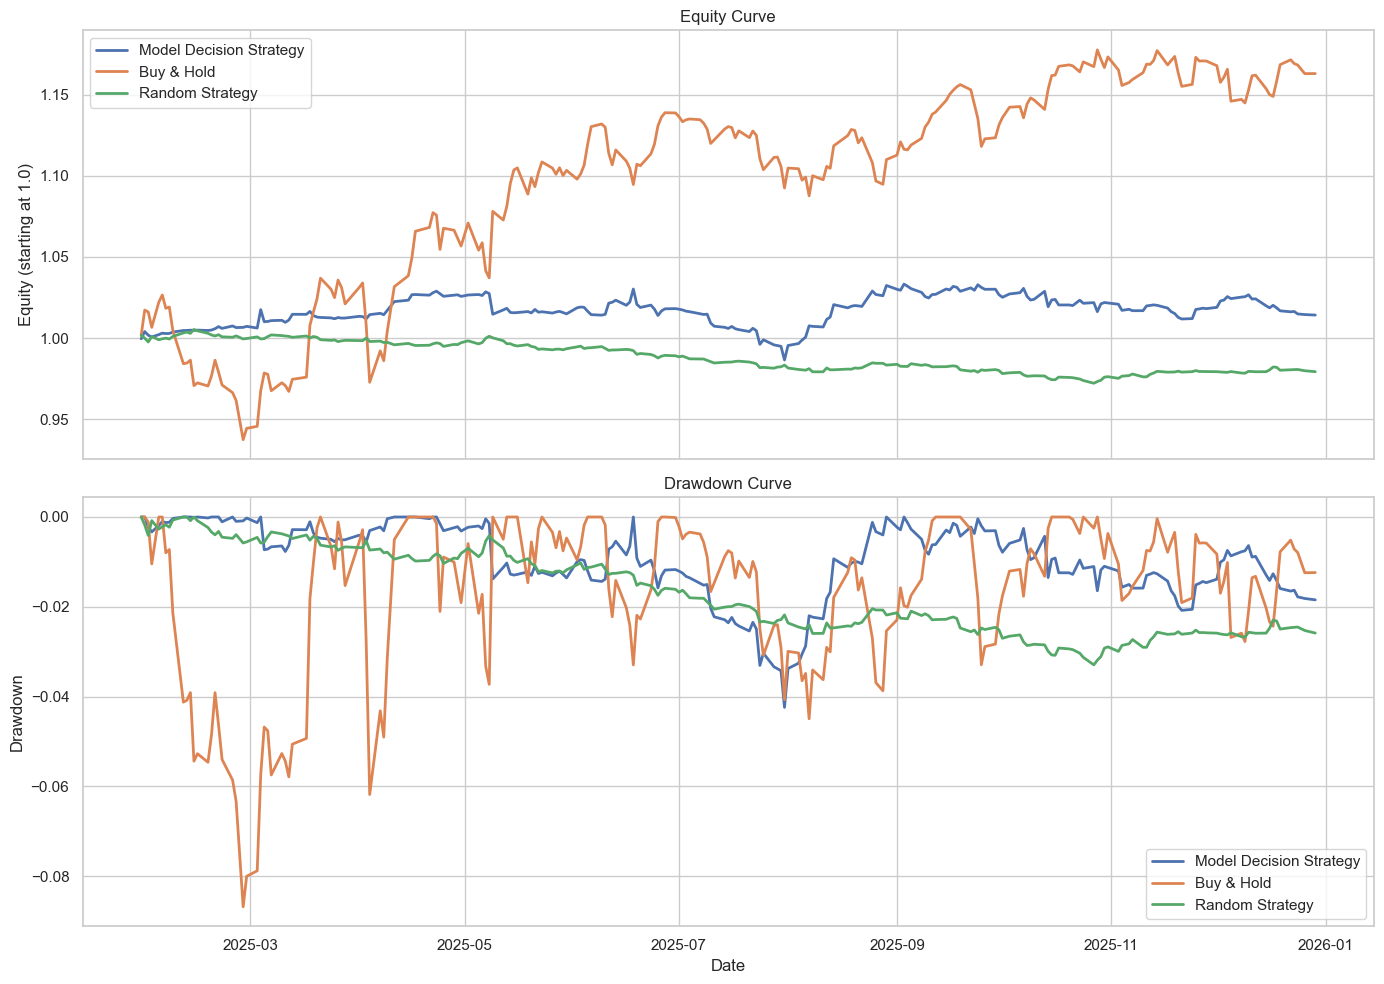

In [6]:
daily_curve = (
    bt_df.groupby('Date', as_index=False)[['strategy_return', 'buy_hold_return', 'random_return']]
    .mean()
    .sort_values('Date')
)

for c in ['strategy_return', 'buy_hold_return', 'random_return']:
    daily_curve[f'{c}_equity'] = (1.0 + daily_curve[c]).cumprod()
    running_max = daily_curve[f'{c}_equity'].cummax()
    daily_curve[f'{c}_drawdown'] = (daily_curve[f'{c}_equity'] / running_max) - 1.0

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(daily_curve['Date'], daily_curve['strategy_return_equity'], label='Model Decision Strategy', linewidth=2)
axes[0].plot(daily_curve['Date'], daily_curve['buy_hold_return_equity'], label='Buy & Hold', linewidth=2)
axes[0].plot(daily_curve['Date'], daily_curve['random_return_equity'], label='Random Strategy', linewidth=2)
axes[0].set_title('Equity Curve')
axes[0].set_ylabel('Equity (starting at 1.0)')
axes[0].legend()

axes[1].plot(daily_curve['Date'], daily_curve['strategy_return_drawdown'], label='Model Decision Strategy', linewidth=2)
axes[1].plot(daily_curve['Date'], daily_curve['buy_hold_return_drawdown'], label='Buy & Hold', linewidth=2)
axes[1].plot(daily_curve['Date'], daily_curve['random_return_drawdown'], label='Random Strategy', linewidth=2)
axes[1].set_title('Drawdown Curve')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6) Regime Analysis (LOW / MEDIUM / HIGH)

,Regime,Samples,Trade Coverage,Total Return,Cumulative Return,Average Return per Trade,Win Rate,Sharpe Ratio,Max Drawdown
0,HIGH,5194,0.0069,0.0123,0.0123,0.0016,0.5278,1.6845,-0.0038
1,LOW,11297,0.6171,0.0004,0.0004,-0.0001,0.4989,0.0434,-0.0844
2,MEDIUM,5301,0.1494,0.0987,0.0987,0.0028,0.5871,1.8780,-0.0210


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_1112\464426423.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regime_perf_df, x='Regime', y='Total Return', palette='viridis')


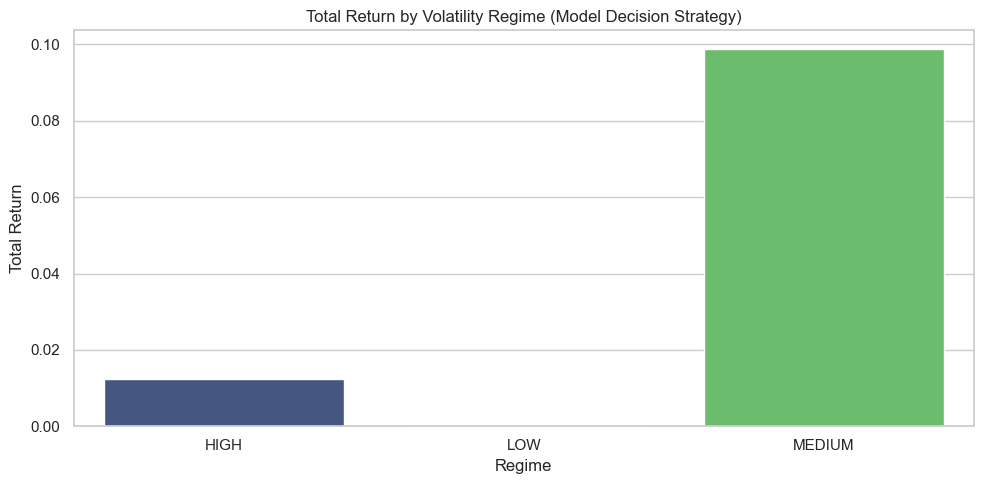

In [7]:
regime_rows = []
for regime, grp in bt_df.groupby('Regime'):
    metrics = strategy_metrics(grp, 'strategy_return', trade_flag_col='trade_executed')
    regime_rows.append({
        'Regime': regime,
        'Samples': int(len(grp)),
        'Trade Coverage': float(grp['trade_executed'].mean()),
        **metrics,
    })

regime_perf_df = pd.DataFrame(regime_rows).sort_values('Regime').reset_index(drop=True)
display(regime_perf_df.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=regime_perf_df, x='Regime', y='Total Return', palette='viridis')
plt.title('Total Return by Volatility Regime (Model Decision Strategy)')
plt.tight_layout()
plt.show()

## 7) Financial Edge Summary

In [8]:
model_row = strategy_summary.set_index('Strategy').loc['Model Decision Strategy']
bh_row = strategy_summary.set_index('Strategy').loc['Buy & Hold']
rand_row = strategy_summary.set_index('Strategy').loc['Random Strategy']

print('Backtesting completed.')
print(f"Model total return: {model_row['Total Return']:.4f}")
print(f"Buy&Hold total return: {bh_row['Total Return']:.4f}")
print(f"Random total return: {rand_row['Total Return']:.4f}")
print(f"Model Sharpe: {model_row['Sharpe Ratio']:.4f} | Buy&Hold Sharpe: {bh_row['Sharpe Ratio']:.4f} | Random Sharpe: {rand_row['Sharpe Ratio']:.4f}")
print(f"Model max drawdown: {model_row['Max Drawdown']:.4f}")

if (model_row['Total Return'] > bh_row['Total Return']) and (model_row['Total Return'] > rand_row['Total Return']):
    print('Conclusion: Model-driven decisions show positive financial edge vs benchmarks on this backtest window.')
else:
    print('Conclusion: Financial edge is not consistently above benchmarks; further refinement is needed.')

Backtesting completed.
Model total return: 0.0142
Buy&Hold total return: 0.1629
Random total return: -0.0206
Model Sharpe: 0.3730 | Buy&Hold Sharpe: 1.2535 | Random Sharpe: -1.4230
Model max drawdown: -0.0424
Conclusion: Financial edge is not consistently above benchmarks; further refinement is needed.
